### 거래 성사율 제고:


아웃소싱 전문가와 고객 간의 거래성사율을 높일 수 있는 요인들을 도출하고, 효과적인 서비스 홍보전략을 수립합니다.


현황: 


동종업계의 공격적인 마케팅


IT전문가들 이탈


서비스간 적정가격 책정의 부재로 고객불만 증가


아웃소싱 거래가 어플리케이션 외의 개인적인 연락으로 전환되어 거래 지속성 감소. 


이로 인한 거래 성사율 정체 및 전문가 이탈 심화되면 수수료 기반 매출유지 어려울 것으로 우려됨.


거래 성사율 개선 및 적정 수수료 책정방안 도출 시급.

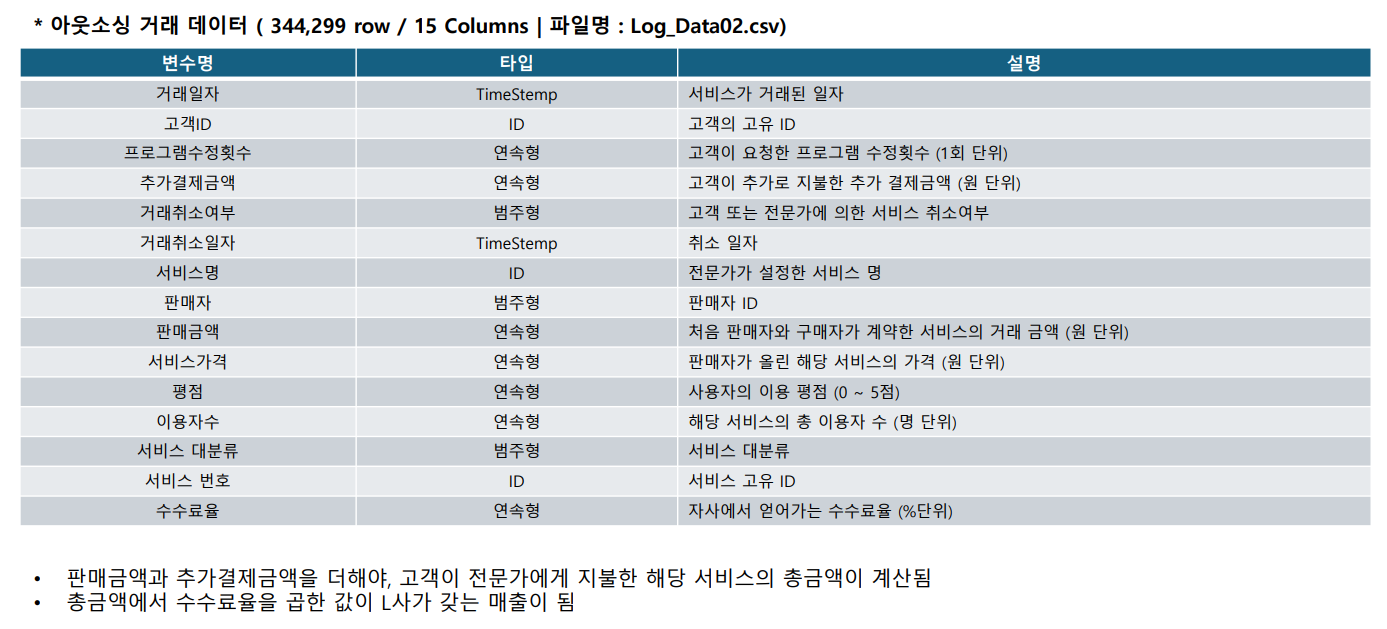

In [1]:
import pandas as pd

df = pd.read_csv("Log_Data02.csv")
df.head(3)

,거래일자,수수료율,고객ID,프로그램수정횟수,추가결제금액,거래취소여부,거래취소일자,서비스명,판매자,판매금액,서비스가격,평점,이용자수,대분류,서비스번호
0,20210201,6.5,5.030100e+09,0.0,9800,NaN,NaN,"카페24,고도몰,메이크샵등 쇼핑몰 수정,코딩,유지보수",logf1,14800.0,5000.0,5.0,584.0,커머스,2102.0
1,20210201,6.5,8.020105e+09,0.0,0,NaN,NaN,"카페24,고도몰,메이크샵등 쇼핑몰 수정,코딩,유지보수",logf1,5000.0,5000.0,5.0,584.0,커머스,2102.0
2,20210201,6.5,1.100000e+11,0.0,9200,NaN,NaN,"엑셀 VBA, 매크로, ERP 프로그램 개발해 드립니다.",엑셀의신,19200.0,10000.0,5.0,583.0,데이터,2103.0


In [2]:
df.columns

Index(['거래일자', '수수료율', '고객ID', '프로그램수정횟수', '추가결제금액', '거래취소여부', '거래취소일자',
       '서비스명', '판매자', '판매금액', '서비스가격', '평점', '이용자수', '대분류', '서비스번호'],
      dtype='object')

* 서비스가격, 판매금액, 추가결제금액 관련 거래금액 규모에 따라 수수료율 차등 가능성
* 프로그램 수정횟수 관련 고객지원 비용 증가시 수수료율 인상 검토
* 평점, 이용자수 관련 품질 신뢰도 높은 판매자는 수수료율 인하 검토
* 거래취소여부 관련 리스크가 높으면 수수료율 인상 검토
* 대분류, 서비스명, 판매자 관련 업종, 판매자에 따른 수수료 정책 구현
* 같은 조건인데 수수료율이 현저히 낮거나 높은 경우 협상 대상. IQR, Z-score 등으로 탐지
* 수수료율 조정시 총수익(판매금액 * 수수료율)이 최적화되는 지점 찾기

In [3]:
df['서비스명'].value_counts()

서비스명
VBA 프로그램 , 엑셀 매크로 제작해 드립니다.           3738
리눅스 기술지원, 장애처리, 서버이전, 서버구축            3727
카페24,고도몰,메이크샵,모든쇼핑몰 수정,오류,문제해결        2851
생산,재고,급여,데이터 엑셀화로 업무의 효율을 높여 드립니다.    2729
고퀄리티의 퍼블리싱을 구현해 드립니다.                 2482
                                      ... 
카페24 쇼핑몰 디자인 작업해드립니다                     1
ML/AI Modeling 진행해드립니다.                  1
언리얼 상업 게임 개발해드립니다.                       1
반응형 랜딩페이지부터 원페이지까지 퍼블리싱해 드립니다.           1
디스코드 봇 주문제작 드립니다.                        1
Name: count, Length: 2787, dtype: int64

In [4]:
df.drop(['거래일자', '고객ID', '서비스번호', '거래취소일자'], axis=1, inplace=True) # 데이터 분석시 불필요한 컬럼 삭제
df.head(3)

,수수료율,프로그램수정횟수,추가결제금액,거래취소여부,서비스명,판매자,판매금액,서비스가격,평점,이용자수,대분류
0,6.5,0.0,9800,NaN,"카페24,고도몰,메이크샵등 쇼핑몰 수정,코딩,유지보수",logf1,14800.0,5000.0,5.0,584.0,커머스
1,6.5,0.0,0,NaN,"카페24,고도몰,메이크샵등 쇼핑몰 수정,코딩,유지보수",logf1,5000.0,5000.0,5.0,584.0,커머스
2,6.5,0.0,9200,NaN,"엑셀 VBA, 매크로, ERP 프로그램 개발해 드립니다.",엑셀의신,19200.0,10000.0,5.0,583.0,데이터


In [5]:
# 총금액 컬럼 생성 및 기존 컬럼 삭제

df['총금액'] = df['판매금액'] * df['이용자수']
df.drop(['판매금액', '추가결제금액'], axis=1, inplace=True)
df.head(3)


,수수료율,프로그램수정횟수,거래취소여부,서비스명,판매자,서비스가격,평점,이용자수,대분류,총금액
0,6.5,0.0,NaN,"카페24,고도몰,메이크샵등 쇼핑몰 수정,코딩,유지보수",logf1,5000.0,5.0,584.0,커머스,8643200.0
1,6.5,0.0,NaN,"카페24,고도몰,메이크샵등 쇼핑몰 수정,코딩,유지보수",logf1,5000.0,5.0,584.0,커머스,2920000.0
2,6.5,0.0,NaN,"엑셀 VBA, 매크로, ERP 프로그램 개발해 드립니다.",엑셀의신,10000.0,5.0,583.0,데이터,11193600.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344299 entries, 0 to 344298
Data columns (total 10 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   수수료율      344299 non-null  float64
 1   프로그램수정횟수  344299 non-null  float64
 2   거래취소여부    4597 non-null    float64
 3   서비스명      344277 non-null  object 
 4   판매자       344277 non-null  object 
 5   서비스가격     344277 non-null  float64
 6   평점        344277 non-null  float64
 7   이용자수      344277 non-null  float64
 8   대분류       344277 non-null  object 
 9   총금액       344277 non-null  float64
dtypes: float64(7), object(3)
memory usage: 26.3+ MB


* 본 데이터셋은 범주형 자료가 많아 Catboost로 진행
| 항목            | **XGBoost**             | **LightGBM**            | **CatBoost**            |
| ------------- | ----------------------- | ----------------------- | ----------------------- |
| **개발사**       | DMLC(Open-source)       | Microsoft               | Yandex (러시아)            |
| **데이터 처리 방식** | Level-wise (균형 트리 성장)   | Leaf-wise (불균형 트리, 성능↑) | Symmetric Tree (균형 트리)  |
| **속도**        | 빠름 (병렬처리 지원)            | 매우 빠름 (Histogram 기반 학습) | 빠름 (전처리 필요 없음)          |
| **범주형 처리**    | ❌ 수동 인코딩 필요 (One-hot 등) | ⚠️ 수동 인코딩 필요 (Label 등)  | ✅ 자동 처리 (One-hot 필요 없음) |
| **결측값 처리**    | ✅ 자동 처리                 | ✅ 자동 처리                 | ✅ 자동 처리                 |
| **GPU 지원**    | ✅ (`gpu_hist`)          | ✅ (`device='gpu'`)      | ✅ (`task_type='GPU'`)   |
| **사용 용도**     | 가장 보편적                  | 대규모 데이터, 빠른 성능 중요할 때    | 범주형 데이터 많을 때 적합         |


In [7]:
# !pip install catboost

In [8]:
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np

import pandas as pd
from sklearn.model_selection import train_test_split

# 1. 사용할 컬럼 정의
target = '수수료율'
features = ['프로그램수정횟수', '거래취소여부', '서비스명', '판매자', '서비스가격', '평점', '이용자수', '대분류', '총금액']
cat_features = ['서비스명', '판매자', '대분류']  # CatBoost용 범주형 변수

# 2. 타겟 결측 제거
df = df[df[target].notnull()].copy()

# 3. 수치형 컬럼 결측치 처리 (선택: 0으로 채우기 또는 평균 등)
numeric_cols = ['프로그램수정횟수', '거래취소여부', '서비스가격', '평점', '이용자수', '총금액']
df[numeric_cols] = df[numeric_cols].fillna(0)

# 4. 범주형 컬럼 결측값 처리 + 문자열 변환
for col in cat_features:
    df[col] = df[col].fillna('Missing').astype(str)

# 5. 학습/테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    df[features], df[target], test_size=0.2, random_state=42
)



In [9]:
from catboost import CatBoostRegressor

model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    cat_features=cat_features,
    loss_function='RMSE',
    verbose=100,
    random_seed=42
)

model.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=50)


0:	learn: 0.7883436	test: 0.7915422	best: 0.7915422 (0)	total: 266ms	remaining: 4m 25s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.791542248
bestIteration = 0

Shrink model to first 1 iterations.


| 항목                                       | 설명                                                      |
| ---------------------------------------- | ------------------------------------------------------- |
| **`bestIteration = 5`**                  | 검증 데이터(RMSE 기준)에서 가장 좋은 성능을 낸 반복은 **5회**                |
| **`Stopped by overfitting detector`**    | 이후 **50번 반복 동안 성능이 더 이상 향상되지 않아서 중단됨** (early stopping) |
| **`Shrink model to first 6 iterations`** | 최적 반복 횟수까지만 모델을 줄여서 최종 모델 생성됨                           |
| **`bestTest = 0.7915`**                  | 검증 데이터셋에서의 **RMSE (Root Mean Squared Error)** 값         |


In [10]:
df['수수료율'].describe() 
# 수수료율은 6.5%에서 9% 사이이며, 평균은 6.95% 
# RMSE는 예측값과 실제값의 평균적인 차이를 뜻하므로, 수수료율이 6.5와 9 사이의 값으로 
# 범위가 2.5이나 RMSE가 0.7915이므로 이는 전체 범위의 31.7%로서 큰 오차에 해당
# 큰 오차에 해당되어 모델개선 필요. 
# 우선 개선이 필요한 모델이므로 데이터 전처리, 피처엔지니어링, 하이퍼파라미터 튜닝 등 필요

count    344299.000000
mean          6.950001
std           0.788989
min           6.500000
25%           6.500000
50%           6.500000
75%           7.500000
max           9.000000
Name: 수수료율, dtype: float64

In [11]:
X_train.columns

Index(['프로그램수정횟수', '거래취소여부', '서비스명', '판매자', '서비스가격', '평점', '이용자수', '대분류',
       '총금액'],
      dtype='object')

C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


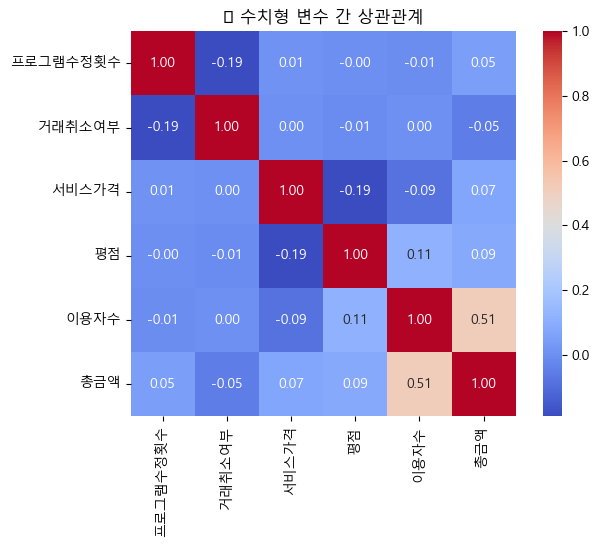

📌 높은 상관관계를 가진 변수쌍:
Series([], dtype: float64)


In [12]:
# 수치형 변수에서 상관관계가 높은 변수 추출
# 절대 상관관계 0.8 이상인 쌍만 추출

import seaborn as sns
import matplotlib.pyplot as plt

# 수치형 변수만 선택
numeric_cols = ['프로그램수정횟수', '거래취소여부', '서비스가격', '평점', '이용자수', '총금액']

# 상관계수 계산
corr_matrix = X_train[numeric_cols].corr()

# 시각화
plt.figure(figsize=(7, 5))
plt.rcParams['font.family'] = 'Malgun Gothic'
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("📊 수치형 변수 간 상관관계")
plt.show()

high_corr = corr_matrix.abs().unstack().sort_values(ascending=False)
high_corr = high_corr[high_corr < 1]  # 자기 자신 제외
high_corr = high_corr[high_corr > 0.8]  # 0.8 초과인 쌍

print("📌 높은 상관관계를 가진 변수쌍:")
print(high_corr)


In [13]:
df.drop('서비스가격', axis=1, inplace=True)

In [14]:
# 1. 사용할 컬럼 정의
target = '수수료율'
features = ['프로그램수정횟수', '거래취소여부', '서비스명', '판매자', '평점', '이용자수', '대분류', '총금액']
cat_features = ['서비스명', '판매자', '대분류']  # CatBoost용 범주형 변수

# 2. 타겟 결측 제거
df = df[df[target].notnull()].copy()

# 3. 수치형 컬럼 결측치 처리 (선택: 0으로 채우기 또는 평균 등)
numeric_cols = ['프로그램수정횟수', '거래취소여부', '평점', '이용자수', '총금액']
df[numeric_cols] = df[numeric_cols].fillna(0)

# 4. 범주형 컬럼 결측값 처리 + 문자열 변환
for col in cat_features:
    df[col] = df[col].fillna('Missing').astype(str)

# 5. 학습/테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    df[features], df[target], test_size=0.2, random_state=42
)

from catboost import CatBoostRegressor

model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    cat_features=cat_features,
    loss_function='RMSE',
    verbose=100,
    random_seed=42
)

model.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=50)


0:	learn: 0.7883415	test: 0.7915473	best: 0.7915473 (0)	total: 101ms	remaining: 1m 40s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7915472984
bestIteration = 0

Shrink model to first 1 iterations.


In [15]:
df.head(3)

,수수료율,프로그램수정횟수,거래취소여부,서비스명,판매자,평점,이용자수,대분류,총금액
0,6.5,0.0,0.0,"카페24,고도몰,메이크샵등 쇼핑몰 수정,코딩,유지보수",logf1,5.0,584.0,커머스,8643200.0
1,6.5,0.0,0.0,"카페24,고도몰,메이크샵등 쇼핑몰 수정,코딩,유지보수",logf1,5.0,584.0,커머스,2920000.0
2,6.5,0.0,0.0,"엑셀 VBA, 매크로, ERP 프로그램 개발해 드립니다.",엑셀의신,5.0,583.0,데이터,11193600.0


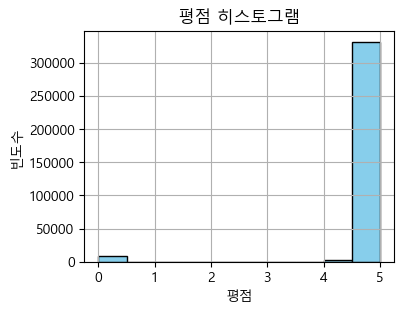

In [16]:
import matplotlib.pyplot as plt

# Draw histogram
plt.figure(figsize=(4, 3))  # Optional: set the size of the plot
plt.hist(df['평점'], bins=10, color='skyblue', edgecolor='black')  # You can change bins as needed
plt.title('평점 히스토그램')
plt.xlabel('평점')
plt.ylabel('빈도수')
plt.grid(True)
plt.show()


In [17]:
df[df['평점']==0]

,수수료율,프로그램수정횟수,거래취소여부,서비스명,판매자,평점,이용자수,대분류,총금액
1396,6.5,0.0,0.0,"엑셀 문서 작성해드립니다. VBA,매크로,파워쿼리",엑셀로칼퇴,0.0,0.0,데이터,0.0
1397,7.5,0.0,0.0,"엑셀 문서 작성해드립니다. VBA,매크로,파워쿼리",엑셀로칼퇴,0.0,0.0,데이터,0.0
1398,6.5,0.0,0.0,"엑셀 문서 작성해드립니다. VBA,매크로,파워쿼리",엑셀로칼퇴,0.0,0.0,데이터,0.0
1399,6.5,0.0,0.0,"엑셀 문서 작성해드립니다. VBA,매크로,파워쿼리",엑셀로칼퇴,0.0,0.0,데이터,0.0
1400,6.5,0.0,0.0,"엑셀 문서 작성해드립니다. VBA,매크로,파워쿼리",엑셀로칼퇴,0.0,0.0,데이터,0.0
...,...,...,...,...,...,...,...,...,...
344282,6.5,0.0,0.0,"홈페이지 간단하면서도 ""느낌있게"" 제작 해드립니다",FranciscoXavier,0.0,0.0,홈페이지,0.0
344283,6.5,0.0,0.0,"홈페이지 간단하면서도 ""느낌있게"" 제작 해드립니다",FranciscoXavier,0.0,0.0,홈페이지,0.0
344284,6.5,1.0,0.0,"홈페이지 간단하면서도 ""느낌있게"" 제작 해드립니다",FranciscoXavier,0.0,0.0,홈페이지,0.0
344285,6.5,0.0,0.0,"홈페이지 간단하면서도 ""느낌있게"" 제작 해드립니다",FranciscoXavier,0.0,0.0,홈페이지,0.0


In [18]:
bin_labels = pd.cut(df['평점'], bins=10)
frequency_table = bin_labels.value_counts().sort_index()
print(frequency_table)

평점
(-0.005, 0.5]      9197
(0.5, 1.0]           10
(1.0, 1.5]            0
(1.5, 2.0]            0
(2.0, 2.5]            8
(2.5, 3.0]           73
(3.0, 3.5]          210
(3.5, 4.0]         2082
(4.0, 4.5]         2795
(4.5, 5.0]       329924
Name: count, dtype: int64


In [19]:
df['대분류'].value_counts()

대분류
홈페이지       124007
데이터         61680
기타          44769
프로그래밍       32758
커머스         26802
프로그램        24973
모바일         15972
디자인          4235
기획           3930
게임           3026
인공지능         1412
UnReal        713
Missing        22
Name: count, dtype: int64

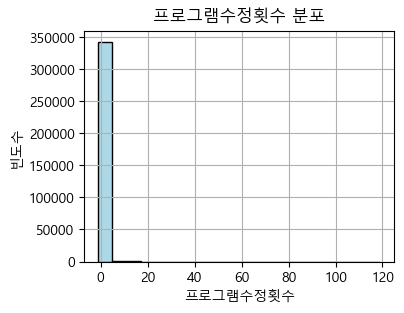

In [20]:
plt.figure(figsize=(4, 3))
plt.hist(df['프로그램수정횟수'], bins=20, edgecolor='black', color='lightblue')
plt.title('프로그램수정횟수 분포')
plt.xlabel('프로그램수정횟수')
plt.ylabel('빈도수')
plt.grid(True)
plt.show()

In [21]:
df['프로그램수정횟수'].describe()

count    344299.000000
mean          0.173583
std           0.722254
min          -1.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         119.000000
Name: 프로그램수정횟수, dtype: float64

In [22]:
Q1 = df['프로그램수정횟수'].quantile(0.25)
Q3 = df['프로그램수정횟수'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(upper_bound) # 대부분 0으로 편중되어 upper_bound가 0으로 나오므로 IQR사용불가

0.0


In [23]:
# 비정상적인 수
df['프로그램수정횟수'] = df['프로그램수정횟수'].apply(lambda x: 40 if x >= 40 else x)
df['프로그램수정횟수'].describe()

count    344299.000000
mean          0.173342
std           0.695899
min          -1.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          40.000000
Name: 프로그램수정횟수, dtype: float64

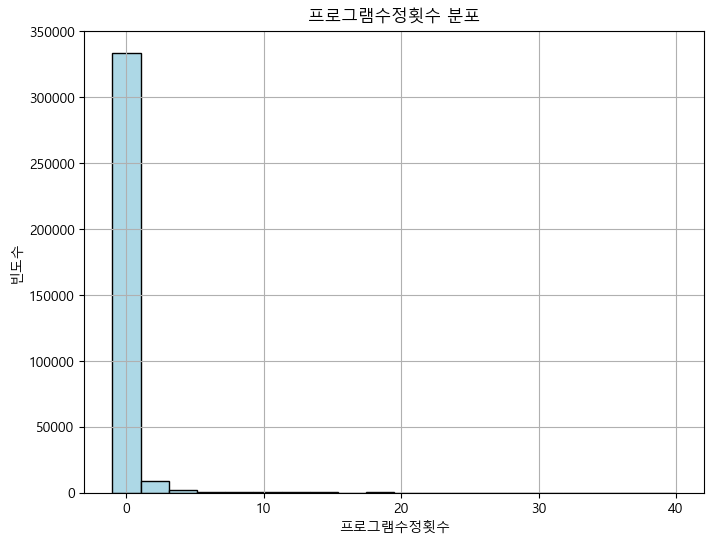

In [24]:
plt.figure(figsize=(8, 6))
plt.hist(df['프로그램수정횟수'], bins=20, edgecolor='black', color='lightblue')
plt.title('프로그램수정횟수 분포')
plt.xlabel('프로그램수정횟수')
plt.ylabel('빈도수')
plt.grid(True)
plt.show()

In [25]:
df['거래취소여부'].value_counts()

거래취소여부
0.0    339702
1.0      4597
Name: count, dtype: int64

In [26]:
df.columns

Index(['수수료율', '프로그램수정횟수', '거래취소여부', '서비스명', '판매자', '평점', '이용자수', '대분류',
       '총금액'],
      dtype='object')

In [27]:
# 과도한 문자열 연산을 줄이기 위해 서비스명 삭제
df.drop('서비스명', axis=1, inplace=True)

In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error

# 2. 타겟과 피처 분리
X = df.drop('수수료율', axis=1)
y = df['수수료율']

# 3. 학습/테스트 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. 범주형 변수 추출
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# 5. CatBoost 모델 정의
model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    loss_function='RMSE',
    cat_features=cat_features,
    verbose=100,
    random_seed=42
)

# 6. 모델 학습
model.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=50)

# 7. 예측 및 평가
y_pred = model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f" RMSE (수수료율): {rmse:.4f}")


0:	learn: 0.7883394	test: 0.7915427	best: 0.7915427 (0)	total: 81.9ms	remaining: 40.9s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7915427368
bestIteration = 0

Shrink model to first 1 iterations.
 RMSE (수수료율): 0.7915


C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


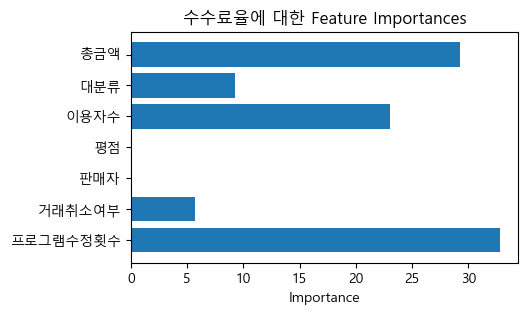

In [29]:
import matplotlib.pyplot as plt

feature_importances = model.get_feature_importance()
features = X.columns

plt.figure(figsize=(5, 3))
plt.barh(features, feature_importances)
plt.title('수수료율에 대한 Feature Importances')
plt.xlabel('Importance')
plt.show()


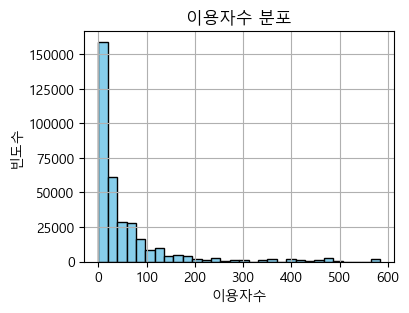

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 3))
plt.hist(df['이용자수'], bins=30, color='skyblue', edgecolor='black')
plt.title('이용자수 분포')
plt.xlabel('이용자수')
plt.ylabel('빈도수')
plt.grid(True)
plt.show()


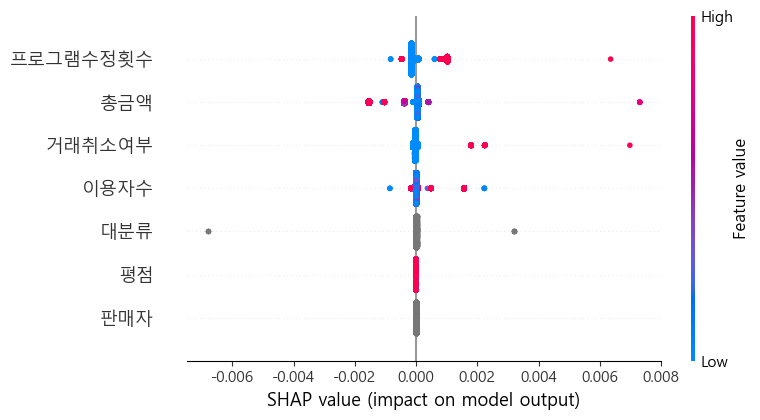

In [31]:
import shap
shap.initjs()

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

* 총금액, 평점, 대분류 순으로 중요한 피처.다만 0에 가까이 몰려있어 모든 피처가 약하게 영향을 미쳤다.
* X축은 SHAP value로 기여도이며 음수라면 수수료율을 낮추는 방향, 양수라면 수수료율을 높이는 방향
* 빨간색은 해당 피처값이 큰 경우, 파란색은 해당 피처값이 작은 경우
* 총금액은 빨간점이 오른쪽에 특별히 몰려있는 경향이 없고, 일부 빨간점이 왼쪽에도 있다는 것은 총 금액이 크더라도 수수료율을 낮추는 방향으로 작용한 경우도 존재
* 총금액은 모델이 중요하게 보는 피처 중 하나지만, 그 값이 클 때 수수료율을 높이기도 하고, 낮추기도 하는 이중적인 역할
* 빨간점(높은 평점)이 대체로 양의 SHAP에 분포하여 수수료율을 높이는 방향으로 작용.
* 높은 평점을 받은 서비는 품질이 높고 사용자 만족도가 높이 가격 프리미엄이 붙을 수 있으며,
* L사가 그러한 서비스에 대해 높은 수수료율을 부과한 것으로 보이며,
* 이런 경우 수수료율을 낮추는 것이 장기적인 안목에서 바람직 

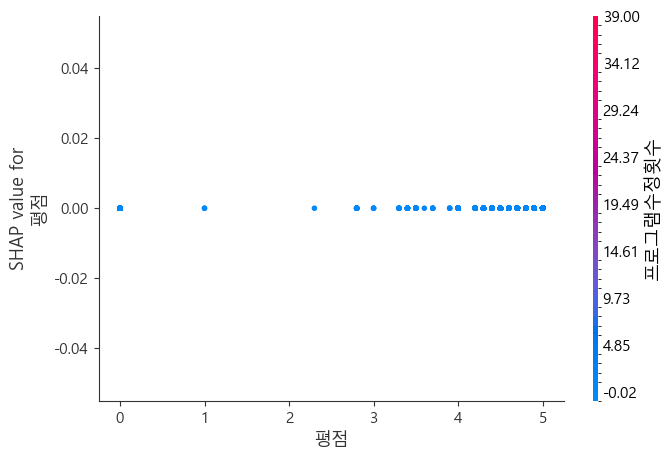

In [32]:
import shap
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

shap.dependence_plot('평점', shap_values, X_test, feature_names=X_test.columns)
# 평점이 높아질 수록 SHAP값은 올라가는 경항도, 내려가는 경향도 보인다.
# 이 모델이 성능이 낮은 이유는 변수들이 수수료율에 미치는 영향이 양면적이기 때문이다. 비선형모델이 바람직.
# 4-5의 높은 평점의 shap값이 대부분 0이어서 높은 평점은 수수료율에 큰 영향을 주지 않는다. 
# 0-2의 낮은 평점은 음수로 떨어지는 점들이 있어 수수료율을 낮추는 방향으로 존재하나, 
# 평점도 낮고, 총금액도 낮으면 수수료율을 낮추는 경향이 심화

In [33]:
# 각각의 샘플에 대한 해석
shap.force_plot(explainer.expected_value, shap_values[0], X_test.iloc[0])


* 모델이 이 샘플에 대해 예측한 최종 수수료율은 6.95이며,
* 전체 데이터의 평균 예측값(모든 피처를 무시했을 때 평균 수수료율)도 6.95이므로,
* SHAP 기여도의 값이 0으로 수렴한 상태
* 빨간색인 평점과 총금액은 오른쪽으로 밀어내면서 예측값을 증가시키고,
* 파란색은 왼쪽으로 밀어내면서 예측값을 감소시킨다.
* 샘플과 같이 평점이 5라면 이 샘풀의 평점이 높은 수준이므로 예측 수수료율을 높였으며,
* 총금액도 높은 편에 속하여 예측값을 높이도록 기여했다.
* 다만 홈페이지라는 대분류는 수수료율을 낮추는 경향을 보여주어, 홈페이지관련해서는 수수료율이 낮게 책정되는 경향이 있다. 

### 수수료율에 따른 이익함수 모델링
* 전문가집단은 수수료를 낮추기를 원하며, L사는 수수료를 높이고 싶다는 이해관계 충돌
* L사의 이익은 수수료율 * 거래금액 * 거래량
* 전문가 집단의 이익은 (1 - 수수료율) * 거래금액 * 거래량
* 수수료가 너무 높으면 이탈하거나 거래량이 줄어드므로 거래량은 수수료율에 대해 역함수 관계
* 양축의 최소 요구수준 min untilty 를 기준으로 서로가 상대적으로 가장 덜 손해보고 만족하는 지점을 찾는다.
* Nash Bargaining Solution

In [34]:
df['총금액'].mean()/df['이용자수'].mean()

25965.86733103169

In [35]:
df['이용자수'].mean()

54.795204168469844

In [36]:
df.columns

Index(['수수료율', '프로그램수정횟수', '거래취소여부', '판매자', '평점', '이용자수', '대분류', '총금액'], dtype='object')

In [37]:
# 최적수수료율 산정시 프로그램수정횟수, 거래취소여부, 대분류 반영시 악용가능성 높아 배제
# 판매자ID는 불필요하므로 삭제
df.drop(['프로그램수정횟수', '거래취소여부', '대분류', '판매자'], axis=1, inplace=True)

In [38]:
# 평점이 없는 경우는 3점으로 적용하고, 이용자수 없는 데이터는 배제
df.drop(df[df['이용자수'] == 0].index, inplace=True)
df.loc[df['평점'] == 0, '평점'] = 3

In [39]:
# 이용자수 * 서비스단가가 총금액이므로 중복되는 이용자수 컬럼 삭제
df.drop('이용자수', axis=1, inplace=True)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 335102 entries, 0 to 344298
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   수수료율    335102 non-null  float64
 1   평점      335102 non-null  float64
 2   총금액     335102 non-null  float64
dtypes: float64(3)
memory usage: 10.2 MB


In [41]:
df.describe()

,수수료율,평점,총금액
count,335102.000000,335102.000000,3.351020e+05
mean,6.950226,4.964490,1.461854e+06
std,0.789093,0.126595,3.075571e+06
min,6.500000,1.000000,0.000000e+00
25%,6.500000,5.000000,2.324000e+05
50%,6.500000,5.000000,6.000000e+05
75%,7.500000,5.000000,1.461600e+06
max,9.000000,5.000000,3.589128e+08


C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Linear Regression Results
R² Score  : -0.0000
RMSE      : 0.7920
Coefficients: [9.60877686e-03 3.15996859e-11]
Intercept   : 6.901704707733212


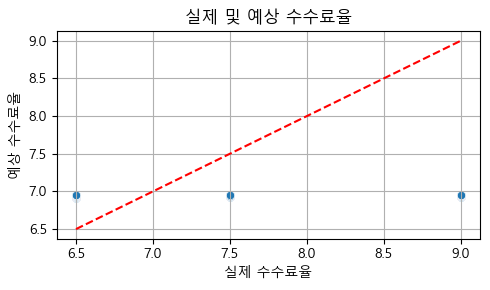

In [42]:
# 📌 Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 📌 Step 3: Feature and target selection
X = df[['평점', '총금액']]  # Features
y = df['수수료율']          # Target

# 📌 Step 4: Split data into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 📌 Step 5: Train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# 📌 Step 6: Predict on test data
y_pred = model.predict(X_test)

# 📌 Step 7: Evaluate the model
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print("Linear Regression Results")
print(f"R² Score  : {r2:.4f}")
print(f"RMSE      : {rmse:.4f}")
print(f"Coefficients: {model.coef_}")
print(f"Intercept   : {model.intercept_}")

# 📌 Step 8: Visualize actual vs predicted
plt.figure(figsize=(5, 3))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('실제 수수료율')
plt.ylabel('예상 수수료율')
plt.title('실제 및 예상 수수료율')
plt.grid(True)
plt.tight_layout()
plt.show()


In [43]:
df

,수수료율,평점,총금액
0,6.5,5.0,8643200.0
1,6.5,5.0,2920000.0
2,6.5,5.0,11193600.0
3,7.5,5.0,30744000.0
4,6.5,5.0,25200000.0
...,...,...,...
344294,9.0,4.6,660000.0
344295,7.5,4.6,660000.0
344296,9.0,4.6,660000.0
344297,6.5,4.6,660000.0


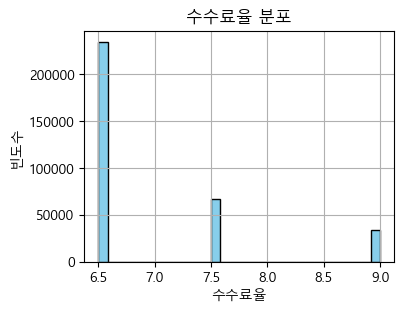

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 3))
plt.hist(df['수수료율'], bins=30, color='skyblue', edgecolor='black')
plt.title('수수료율 분포')
plt.xlabel('수수료율')
plt.ylabel('빈도수')
plt.grid(True)
plt.show()

In [45]:
df['수수료율'].mean()

6.950225602950743

In [46]:
df['수수료율'].max()

9.0

In [47]:
df['수수료율'].min()

6.5

In [180]:
import pandas as pd

df = pd.read_csv("Log_Data02.csv")
df.head(3)

,거래일자,수수료율,고객ID,프로그램수정횟수,추가결제금액,거래취소여부,거래취소일자,서비스명,판매자,판매금액,서비스가격,평점,이용자수,대분류,서비스번호
0,20210201,6.50,5030100140.00,0.00,9800,NaN,NaN,"카페24,고도몰,메이크샵등 쇼핑몰 수정,코딩,유지보수",logf1,14800.00,5000.00,5.00,584.00,커머스,2102.00
1,20210201,6.50,8020105385.00,0.00,0,NaN,NaN,"카페24,고도몰,메이크샵등 쇼핑몰 수정,코딩,유지보수",logf1,5000.00,5000.00,5.00,584.00,커머스,2102.00
2,20210201,6.50,110000000000.00,0.00,9200,NaN,NaN,"엑셀 VBA, 매크로, ERP 프로그램 개발해 드립니다.",엑셀의신,19200.00,10000.00,5.00,583.00,데이터,2103.00


In [181]:
df['판매금액'].sum()

21686862380.0

In [182]:
df.tail(3)

,거래일자,수수료율,고객ID,프로그램수정횟수,추가결제금액,거래취소여부,거래취소일자,서비스명,판매자,판매금액,서비스가격,평점,이용자수,대분류,서비스번호
344296,20210630,9.00,70406002101.00,0.00,0,NaN,NaN,데이터 분석 및 시각화 제공해 드립니다.,전문가오리,20000.00,20000.00,4.60,33.00,데이터,2600.00
344297,20210630,6.50,9010306354.00,0.00,0,NaN,NaN,데이터 분석 및 시각화 제공해 드립니다.,전문가오리,20000.00,20000.00,4.60,33.00,데이터,2600.00
344298,20210630,7.50,9030200780.00,0.00,10000,NaN,NaN,데이터 분석 및 시각화 제공해 드립니다.,전문가오리,30000.00,20000.00,4.60,33.00,데이터,2600.00


In [183]:
df['거래취소여부'].unique()

array([nan,  1.])

In [184]:
# 취소된 건 모두 삭제
df = df[df['거래취소여부'] != 1]
df['거래취소여부'].unique()

array([nan])

In [185]:
df['판매금액'].sum() # 5개월간 매출액이 216억원으로 자료와 불일치. 연간 518억 수준.

21686606880.0

In [186]:
df.columns

Index(['거래일자', '수수료율', '고객ID', '프로그램수정횟수', '추가결제금액', '거래취소여부', '거래취소일자',
       '서비스명', '판매자', '판매금액', '서비스가격', '평점', '이용자수', '대분류', '서비스번호'],
      dtype='object')

In [187]:
df.drop(['거래일자', '고객ID', '프로그램수정횟수', '거래취소여부', '거래취소일자', '서비스번호'], axis=1, inplace=True)
df.head()

,수수료율,추가결제금액,서비스명,판매자,판매금액,서비스가격,평점,이용자수,대분류
0,6.50,9800,"카페24,고도몰,메이크샵등 쇼핑몰 수정,코딩,유지보수",logf1,14800.00,5000.00,5.00,584.00,커머스
1,6.50,0,"카페24,고도몰,메이크샵등 쇼핑몰 수정,코딩,유지보수",logf1,5000.00,5000.00,5.00,584.00,커머스
2,6.50,9200,"엑셀 VBA, 매크로, ERP 프로그램 개발해 드립니다.",엑셀의신,19200.00,10000.00,5.00,583.00,데이터
3,7.50,11000,"엑셀을 이용 서식과 집계, 분석 및 VBA 프로그래밍",태구리,61000.00,50000.00,5.00,504.00,데이터
4,6.50,0,"엑셀을 이용 서식과 집계, 분석 및 VBA 프로그래밍",태구리,50000.00,50000.00,5.00,504.00,데이터


In [188]:
# 총금액 컬럼 생성 후 기존럴럼 삭제
df['총금액'] = df['추가결제금액'] + df['판매금액']
df.drop(['추가결제금액', '판매금액'], axis=1, inplace=True)

In [189]:
df.head()

,수수료율,서비스명,판매자,서비스가격,평점,이용자수,대분류,총금액
0,6.50,"카페24,고도몰,메이크샵등 쇼핑몰 수정,코딩,유지보수",logf1,5000.00,5.00,584.00,커머스,24600.00
1,6.50,"카페24,고도몰,메이크샵등 쇼핑몰 수정,코딩,유지보수",logf1,5000.00,5.00,584.00,커머스,5000.00
2,6.50,"엑셀 VBA, 매크로, ERP 프로그램 개발해 드립니다.",엑셀의신,10000.00,5.00,583.00,데이터,28400.00
3,7.50,"엑셀을 이용 서식과 집계, 분석 및 VBA 프로그래밍",태구리,50000.00,5.00,504.00,데이터,72000.00
4,6.50,"엑셀을 이용 서식과 집계, 분석 및 VBA 프로그래밍",태구리,50000.00,5.00,504.00,데이터,50000.00


In [190]:
df.drop(['서비스가격', '대분류'], axis=1, inplace=True)
df.head()

,수수료율,서비스명,판매자,평점,이용자수,총금액
0,6.50,"카페24,고도몰,메이크샵등 쇼핑몰 수정,코딩,유지보수",logf1,5.00,584.00,24600.00
1,6.50,"카페24,고도몰,메이크샵등 쇼핑몰 수정,코딩,유지보수",logf1,5.00,584.00,5000.00
2,6.50,"엑셀 VBA, 매크로, ERP 프로그램 개발해 드립니다.",엑셀의신,5.00,583.00,28400.00
3,7.50,"엑셀을 이용 서식과 집계, 분석 및 VBA 프로그래밍",태구리,5.00,504.00,72000.00
4,6.50,"엑셀을 이용 서식과 집계, 분석 및 VBA 프로그래밍",태구리,5.00,504.00,50000.00


In [191]:
# 서비스명이 같은 경우 총금액 합산하고 평점과 이용자수는 그대로 유지
df_grouped = df.groupby('서비스명', as_index=False).agg({
    '총금액': 'sum',
    '평점': 'first',      
    '이용자수': 'first',
    '수수료율': 'first'
})
df_grouped.head()

,서비스명,총금액,평점,이용자수,수수료율
0,"""P2P 대출"" 서비스를 위한 기획을 해 드립니다.",2400000.00,0.00,0.00,7.50
1,"""개발 공부 전 필독"" IT 서비스 기본 개념 Ebook을 드립니다.",5065160.00,4.80,9.00,6.50
2,"""디자인 에이전시"" UXUI 화면 설계, 기획안 제작해 드립니다.",889600.00,5.00,1.00,9.00
3,"""디자인적인"" 퍼블리싱 제작해 드립니다.",10130550.00,5.00,16.00,6.50
4,"""반응형 웹 퍼블리싱"" 모든 퍼블리싱 작업 맞춤 진행",28200.00,0.00,0.00,6.50


In [192]:
df_grouped = df_grouped[df_grouped['이용자수'] != 0]
df_grouped.head()

,서비스명,총금액,평점,이용자수,수수료율
1,"""개발 공부 전 필독"" IT 서비스 기본 개념 Ebook을 드립니다.",5065160.00,4.80,9.00,6.50
2,"""디자인 에이전시"" UXUI 화면 설계, 기획안 제작해 드립니다.",889600.00,5.00,1.00,9.00
3,"""디자인적인"" 퍼블리싱 제작해 드립니다.",10130550.00,5.00,16.00,6.50
5,"""웹 크롤링"" 여러분들의 노동 삭제 해 드립니다.",22323110.00,5.00,21.00,6.50
7,"""클래스101 홈페이지 강사""가 세련된 홈페이지 제작해 드립니다.",19966500.00,5.00,4.00,6.50


In [193]:
pd.options.display.float_format = '{:,.1f}'.format

In [194]:
df_grouped.head()

,서비스명,총금액,평점,이용자수,수수료율
1,"""개발 공부 전 필독"" IT 서비스 기본 개념 Ebook을 드립니다.","5,065,160.0",4.8,9.0,6.5
2,"""디자인 에이전시"" UXUI 화면 설계, 기획안 제작해 드립니다.","889,600.0",5.0,1.0,9.0
3,"""디자인적인"" 퍼블리싱 제작해 드립니다.","10,130,550.0",5.0,16.0,6.5
5,"""웹 크롤링"" 여러분들의 노동 삭제 해 드립니다.","22,323,110.0",5.0,21.0,6.5
7,"""클래스101 홈페이지 강사""가 세련된 홈페이지 제작해 드립니다.","19,966,500.0",5.0,4.0,6.5


In [195]:
df_grouped['총금액'].sum() # 대략 198억. 연간환산시 475억원

19814274042.0

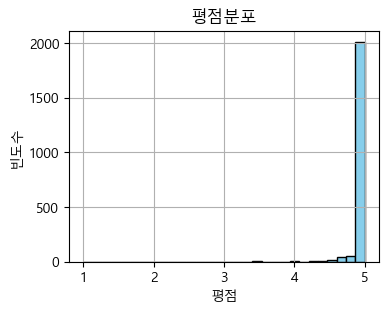

In [196]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 3))
plt.hist(df_grouped['평점'], bins=30, color='skyblue', edgecolor='black')
plt.title('평점분포')
plt.xlabel('평점')
plt.ylabel('빈도수')
plt.grid(True)
plt.show()

In [197]:
df_grouped['평점'].value_counts()


평점
5.0    1875
4.9     138
4.8      51
4.7      32
4.5      12
4.6      10
4.0      10
4.3       8
4.2       3
4.4       3
3.7       2
3.5       2
1.0       2
3.3       1
3.4       1
3.9       1
2.8       1
3.0       1
3.6       1
2.3       1
Name: count, dtype: int64

In [198]:
df_grouped.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2155 entries, 1 to 2786
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   서비스명    2155 non-null   object 
 1   총금액     2155 non-null   float64
 2   평점      2155 non-null   float64
 3   이용자수    2155 non-null   float64
 4   수수료율    2155 non-null   float64
dtypes: float64(4), object(1)
memory usage: 101.0+ KB


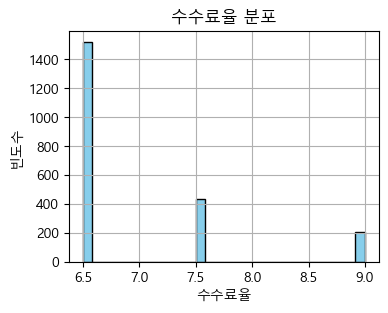

In [199]:
import matplotlib.pyplot as plt
import matplotlib as mpl


mpl.rcParams['font.family'] = 'Malgun Gothic'
plt.figure(figsize=(4, 3))
plt.hist(df_grouped['수수료율'], bins=30, color='skyblue', edgecolor='black')
plt.title('수수료율 분포')
plt.xlabel('수수료율')
plt.ylabel('빈도수')
plt.grid(True)
plt.show()

In [200]:
df_grouped.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2155 entries, 1 to 2786
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   서비스명    2155 non-null   object 
 1   총금액     2155 non-null   float64
 2   평점      2155 non-null   float64
 3   이용자수    2155 non-null   float64
 4   수수료율    2155 non-null   float64
dtypes: float64(4), object(1)
memory usage: 101.0+ KB


In [201]:
df_grouped.head(3)

,서비스명,총금액,평점,이용자수,수수료율
1,"""개발 공부 전 필독"" IT 서비스 기본 개념 Ebook을 드립니다.","5,065,160.0",4.8,9.0,6.5
2,"""디자인 에이전시"" UXUI 화면 설계, 기획안 제작해 드립니다.","889,600.0",5.0,1.0,9.0
3,"""디자인적인"" 퍼블리싱 제작해 드립니다.","10,130,550.0",5.0,16.0,6.5


In [202]:
df_copy = df_grouped.copy()
df_copy

,서비스명,총금액,평점,이용자수,수수료율
1,"""개발 공부 전 필독"" IT 서비스 기본 개념 Ebook을 드립니다.","5,065,160.0",4.8,9.0,6.5
2,"""디자인 에이전시"" UXUI 화면 설계, 기획안 제작해 드립니다.","889,600.0",5.0,1.0,9.0
3,"""디자인적인"" 퍼블리싱 제작해 드립니다.","10,130,550.0",5.0,16.0,6.5
5,"""웹 크롤링"" 여러분들의 노동 삭제 해 드립니다.","22,323,110.0",5.0,21.0,6.5
7,"""클래스101 홈페이지 강사""가 세련된 홈페이지 제작해 드립니다.","19,966,500.0",5.0,4.0,6.5
...,...,...,...,...,...
2782,회로설계 및 PCB 설계 및 제작 해 드립니다.,"10,615,500.0",5.0,21.0,6.5
2783,회사 도메인으로 그룹웨어 메일 수신 설정 도와 드립니다.,"7,673,640.0",5.0,4.0,6.5
2784,"회사업무관리 ERP, MES,WMS 프로그램 개발","79,000.0",5.0,1.0,7.5
2785,효과적인 연락처 수집용 랜딩페이지 제작해 드립니다.,"1,800,000.0",5.0,1.0,6.5


In [203]:
df_copy.head(3)

,서비스명,총금액,평점,이용자수,수수료율
1,"""개발 공부 전 필독"" IT 서비스 기본 개념 Ebook을 드립니다.","5,065,160.0",4.8,9.0,6.5
2,"""디자인 에이전시"" UXUI 화면 설계, 기획안 제작해 드립니다.","889,600.0",5.0,1.0,9.0
3,"""디자인적인"" 퍼블리싱 제작해 드립니다.","10,130,550.0",5.0,16.0,6.5


In [204]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2155 entries, 1 to 2786
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   서비스명    2155 non-null   object 
 1   총금액     2155 non-null   float64
 2   평점      2155 non-null   float64
 3   이용자수    2155 non-null   float64
 4   수수료율    2155 non-null   float64
dtypes: float64(4), object(1)
memory usage: 101.0+ KB


In [205]:
df_copy['수수료율'].unique()

array([6.5, 9. , 7.5])

In [206]:
df_copy['총금액'].sum() # 5개월간 총매출액 198억

19814274042.0

In [207]:
df_copy['영업이익'] = df_copy['총금액'] * df_copy['수수료율'] /100
df_copy.head()

,서비스명,총금액,평점,이용자수,수수료율,영업이익
1,"""개발 공부 전 필독"" IT 서비스 기본 개념 Ebook을 드립니다.","5,065,160.0",4.8,9.0,6.5,"329,235.4"
2,"""디자인 에이전시"" UXUI 화면 설계, 기획안 제작해 드립니다.","889,600.0",5.0,1.0,9.0,"80,064.0"
3,"""디자인적인"" 퍼블리싱 제작해 드립니다.","10,130,550.0",5.0,16.0,6.5,"658,485.8"
5,"""웹 크롤링"" 여러분들의 노동 삭제 해 드립니다.","22,323,110.0",5.0,21.0,6.5,"1,451,002.1"
7,"""클래스101 홈페이지 강사""가 세련된 홈페이지 제작해 드립니다.","19,966,500.0",5.0,4.0,6.5,"1,297,822.5"


In [208]:
df_copy['영업이익'].sum() # 해당기간내 영업이익 13.6억원

1368797262.28

In [209]:
# 매출액대비 영업이익률은 6.9%
df_copy['영업이익'].sum() / df_copy['총금액'].sum() 

0.06908137332604679

In [210]:
# 필요한 영업이익 24.9억원
0.1259 * df_copy['총금액'].sum() 

2494617101.8878

In [211]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2155 entries, 1 to 2786
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   서비스명    2155 non-null   object 
 1   총금액     2155 non-null   float64
 2   평점      2155 non-null   float64
 3   이용자수    2155 non-null   float64
 4   수수료율    2155 non-null   float64
 5   영업이익    2155 non-null   float64
dtypes: float64(5), object(1)
memory usage: 117.9+ KB


In [212]:
df_copy.drop('서비스명', axis=1, inplace=True)
df_copy.columns

Index(['총금액', '평점', '이용자수', '수수료율', '영업이익'], dtype='object')

In [213]:
df_copy.to_csv('df_copy.csv', index=False)


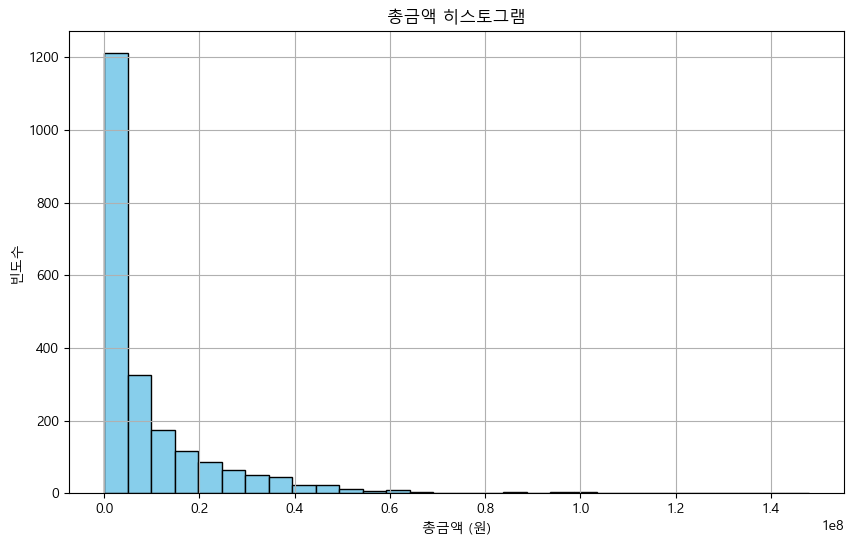

In [214]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df_copy['총금액'], bins=30, color='skyblue', edgecolor='black')
plt.title('총금액 히스토그램')
plt.xlabel('총금액 (원)')
plt.ylabel('빈도수')
plt.grid(True)
plt.show()


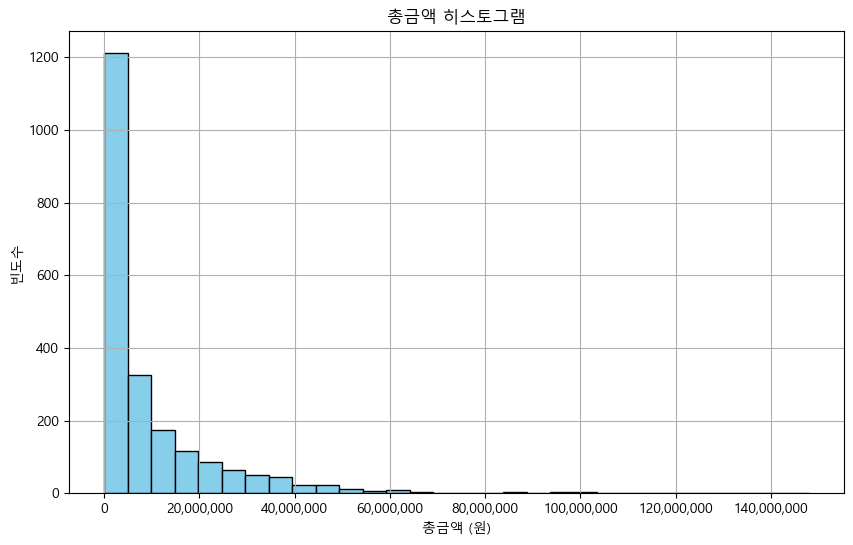

In [215]:
# Re-plot the histogram correctly without using incompatible formatter methods
from matplotlib.ticker import FuncFormatter
plt.figure(figsize=(10, 6))
plt.hist(df_copy['총금액'], bins=30, color='skyblue', edgecolor='black')
plt.title('총금액 히스토그램')
plt.xlabel('총금액 (원)')
plt.ylabel('빈도수')
plt.grid(True)

# Format x-axis with comma-separated values
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.show()


In [216]:
# # 금액별 구간에 따른 수수료율 달리하여 영업이익 증대
# # 기존 영업이익 13.9억원
# def assign_commission(amount):
#     if amount < 40_000_000:
#         return 9
#     elif amount < 80_000_000:
#         return 7.5
#     else:
#         return 6.5

# # 새 컬럼 추가
# df_copy['수수료율'] = df_copy['총금액'].apply(assign_commission)
# df_copy['영업이익'] = df_copy['총금액'] * df_copy['수수료율'] / 100
# df_copy['영업이익'].sum()

In [217]:
df_copy['영업이익'].sum() / df_copy['총금액'].sum()

0.06908137332604679

In [218]:
df_copy.head(3)

,총금액,평점,이용자수,수수료율,영업이익
1,"5,065,160.0",4.8,9.0,6.5,"329,235.4"
2,"889,600.0",5.0,1.0,9.0,"80,064.0"
3,"10,130,550.0",5.0,16.0,6.5,"658,485.8"


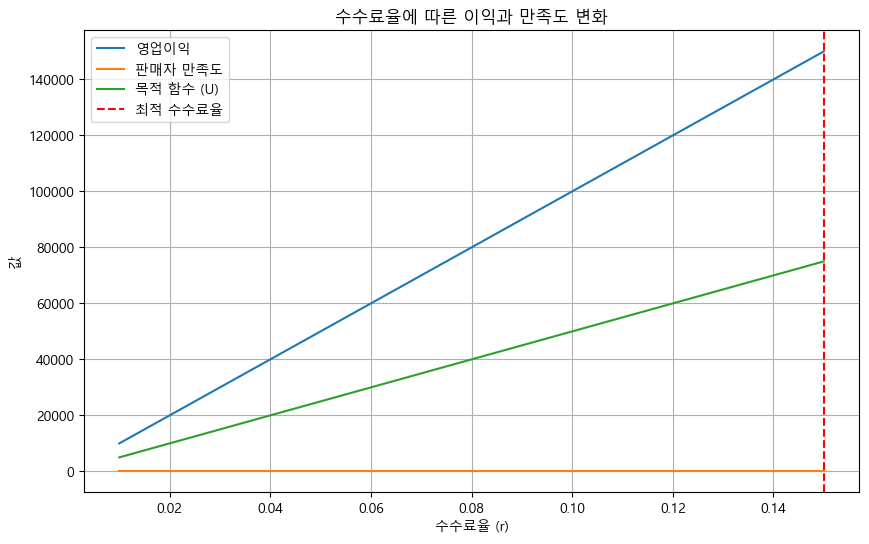

In [219]:
import numpy as np
import matplotlib.pyplot as plt

T = 1000000       # 총금액
k = 5             # 판매자 반응 민감도
lamb = 0.5        # 아웃소싱 회사 이익 가중치

r = np.linspace(0.01, 0.15, 100)
profit = T * r
satisfaction = np.exp(-k * r)
utility = lamb * profit + (1 - lamb) * satisfaction

plt.figure(figsize=(10,6))
plt.plot(r, profit, label='영업이익')
plt.plot(r, satisfaction, label='판매자 만족도')
plt.plot(r, utility, label='목적 함수 (U)')
plt.axvline(x=r[np.argmax(utility)], color='red', linestyle='--', label='최적 수수료율')
plt.title('수수료율에 따른 이익과 만족도 변화')
plt.xlabel('수수료율 (r)')
plt.ylabel('값')
plt.legend()
plt.grid(True)
plt.show()


In [276]:
import pandas as pd
import numpy as np
pd.options.display.float_format = '{:.2f}'.format


a = 0.20  # 최대 수수료율 (20%)
mean_total = df_copy['총금액'].mean()
b = 1 / mean_total  # 총금액에 따른 민감도 설정

# 새로운 수수료율 계산
df_copy['차등_수수료율'] = a * np.exp(-b * df_copy['총금액'])

# 새로운 영업이익 계산
df_copy['예상_영업이익'] = df_copy['총금액'] * df_copy['차등_수수료율']

df_copy[['총금액', '차등_수수료율', '예상_영업이익']][0:5]


,총금액,차등_수수료율,예상_영업이익
1,5065160.00,0.12,583950.61
2,889600.00,0.18,161512.27
3,10130550.00,0.07,673221.63
5,22323110.00,0.02,393892.84
7,19966500.00,0.02,455236.54


In [277]:
b

1.0875997755113717e-07

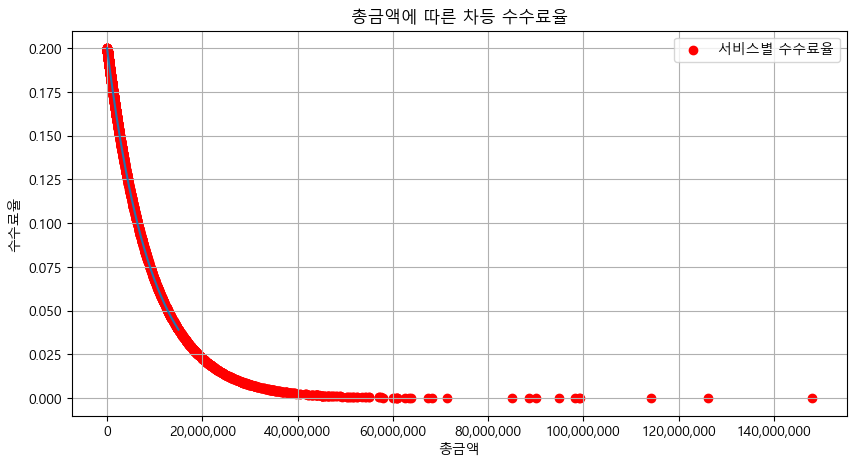

In [278]:
import matplotlib.pyplot as plt

# 수수료율 함수 시각화
T_range = np.linspace(0, 15000000, 300)
r_range = a * np.exp(-b * T_range)

plt.show()
plt.figure(figsize=(10,5))
plt.plot(T_range, r_range)
plt.scatter(df_copy['총금액'], df_copy['차등_수수료율'], color='red', label='서비스별 수수료율')
plt.title('총금액에 따른 차등 수수료율')
plt.xlabel('총금액')
plt.ylabel('수수료율')
plt.grid(True)
plt.legend()
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.show()
plt.show()


In [279]:
df_copy['예상_영업이익'].sum()

720027150.0683135

In [280]:
df_copy['차등_수수료율'] = df_copy['차등_수수료율'].apply(lambda x: 0.06 if x < 0.06 else x)
df_copy['차등_수수료율'].min()

0.06

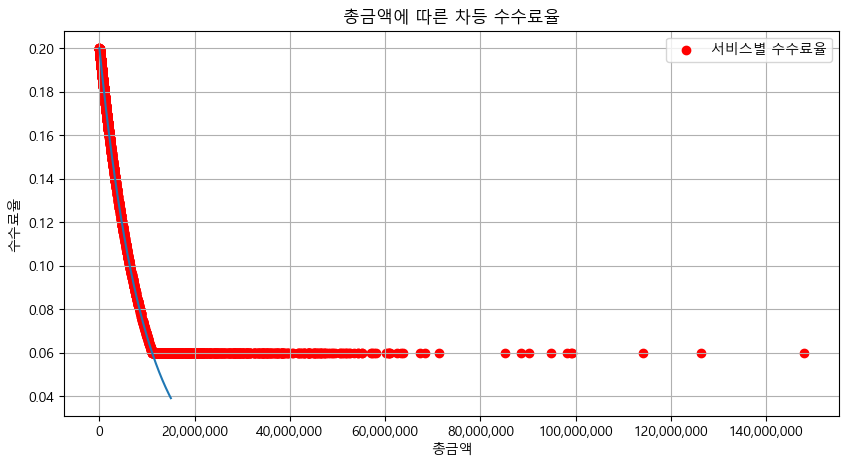

In [281]:
# 수수료율 함수 시각화
T_range = np.linspace(0, 15000000, 300)
r_range = a * np.exp(-b * T_range)

plt.show()
plt.figure(figsize=(10,5))
plt.plot(T_range, r_range)
plt.scatter(df_copy['총금액'], df_copy['차등_수수료율'], color='red', label='서비스별 수수료율')
plt.title('총금액에 따른 차등 수수료율')
plt.xlabel('총금액')
plt.ylabel('수수료율')
plt.grid(True)
plt.legend()
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.show()
plt.show()

In [282]:
df_copy['예상_영업이익'] = df_copy['총금액'] * df_copy['차등_수수료율']
df_copy['예상_영업이익'].sum()

1422900287.2422447

In [283]:
df_copy

,총금액,평점,이용자수,수수료율,영업이익,차등_수수료율,예상_영업이익
1,5065160.00,4.80,9.00,6.50,329235.40,0.12,583950.61
2,889600.00,5.00,1.00,9.00,80064.00,0.18,161512.27
3,10130550.00,5.00,16.00,6.50,658485.75,0.07,673221.63
5,22323110.00,5.00,21.00,6.50,1451002.15,0.06,1339386.60
7,19966500.00,5.00,4.00,6.50,1297822.50,0.06,1197990.00
...,...,...,...,...,...,...,...
2782,10615500.00,5.00,21.00,6.50,690007.50,0.06,669205.39
2783,7673640.00,5.00,4.00,6.50,498786.60,0.09,666155.77
2784,79000.00,5.00,1.00,7.50,5925.00,0.20,15664.83
2785,1800000.00,5.00,1.00,6.50,117000.00,0.16,295993.08


In [292]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2155 entries, 1 to 2786
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   총금액      2155 non-null   float64 
 1   평점       2155 non-null   float64 
 2   이용자수     2155 non-null   float64 
 3   수수료율     2155 non-null   float64 
 4   영업이익     2155 non-null   float64 
 5   차등_수수료율  2155 non-null   float64 
 6   예상_영업이익  2155 non-null   float64 
 7   총금액_구간   2155 non-null   category
dtypes: category(1), float64(7)
memory usage: 138.3 KB


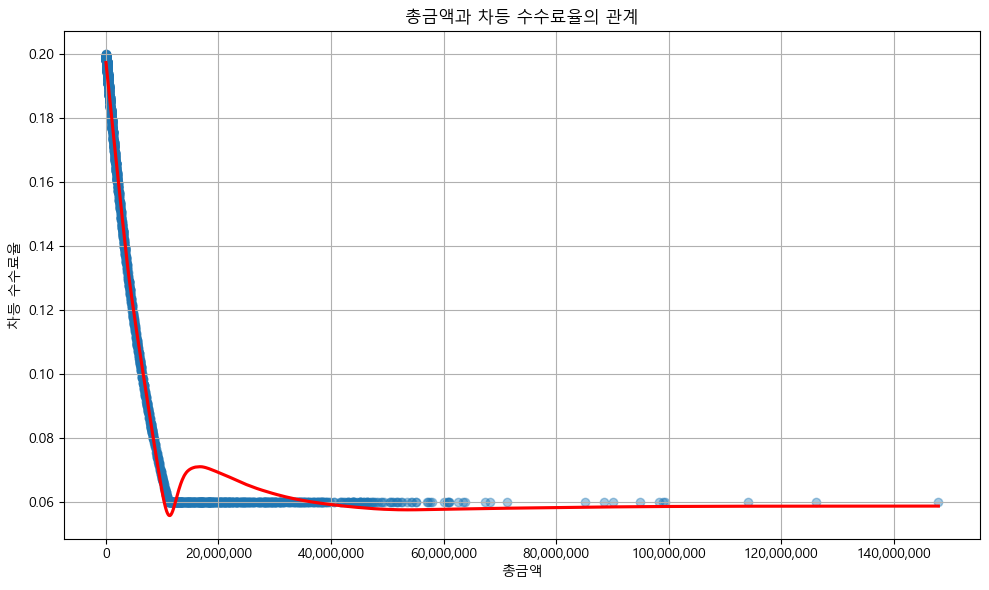

In [297]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# 산점도 + 스무딩 선 (LOWESS)
sns.regplot(x='총금액', y='차등_수수료율', data=df_copy, scatter_kws={'alpha':0.4}, lowess=True, line_kws={'color':'red'})

plt.title('총금액과 차등 수수료율의 관계')
plt.xlabel('총금액')
plt.ylabel('차등 수수료율')
plt.grid(True)
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.show()


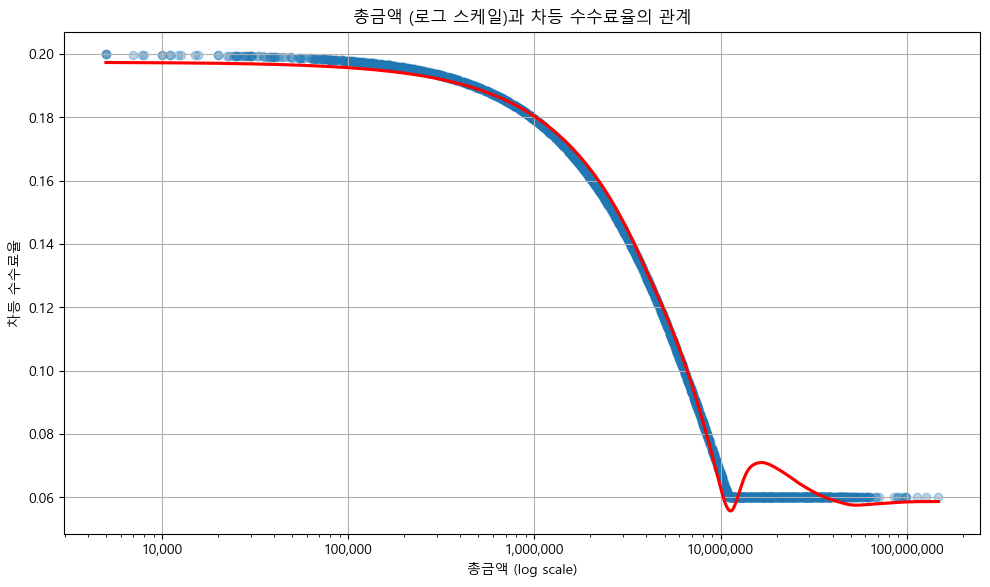

In [298]:
plt.figure(figsize=(10, 6))
sns.regplot(x='총금액', y='차등_수수료율', data=df_copy, scatter_kws={'alpha':0.3}, lowess=True, line_kws={'color':'red'})
plt.xscale('log')  # 로그 스케일 적용

plt.title('총금액 (로그 스케일)과 차등 수수료율의 관계')
plt.xlabel('총금액 (log scale)')
plt.ylabel('차등 수수료율')
plt.grid(True)
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.show()
